# Kolmogorov-Smirnov Test

The **KS test** measures the maximum absolute difference between the empirical CDF and the theoretical (or reference) CDF. It works for both one-sample (vs a distribution) and two-sample (comparing two datasets) cases.

| Variant | H₀ | Test statistic |
|---|---|---|
| **One-sample** | Data follows distribution F₀ | D = max|Fₙ(x) − F₀(x)| |
| **Two-sample** | Both samples from same distribution | D = max|Fₙ₁(x) − Fₙ₂(x)| |

| Property | Value |
|---|---|
| **Distribution-free** | No parametric assumption on the data distribution |
| **Sensitivity** | More sensitive to centre of distribution; AD is better for tails |
| **Continuity** | Requires continuous distributions; for discrete use chi-square GOF |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

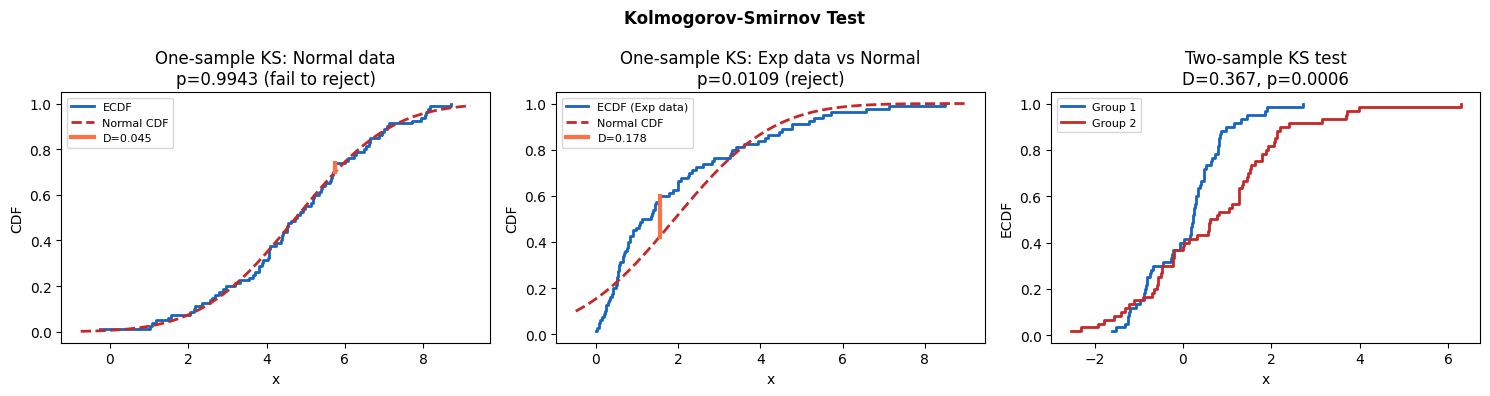

One-sample KS (normal data):  D=0.0453, p=0.9943
One-sample KS (exp vs normal): D=0.1781, p=0.0109
Two-sample KS: D=0.3667, p=0.0006


In [2]:
np.random.seed(42)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Kolmogorov-Smirnov Test', fontsize=12, fontweight='bold')

# One-sample KS: Normal data vs Normal distribution
n = 80
data_norm = np.random.normal(5, 2, n)
data_exp  = np.random.exponential(2, n)

# Empirical CDFs
def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(data)+1) / len(data)
    return x, y

x_norm, y_norm = ecdf(data_norm)
x_exp,  y_exp  = ecdf(data_exp)

# One-sample vs Normal
ks_stat_n, ks_p_n = stats.kstest(data_norm, 'norm',
                                   args=(data_norm.mean(), data_norm.std()))
ks_stat_e, ks_p_e = stats.kstest(data_exp, 'norm',
                                   args=(data_exp.mean(), data_exp.std()))

# Panel 1: ECDF vs theoretical (normal data)
x_range = np.linspace(data_norm.min()-0.5, data_norm.max()+0.5, 300)
theory_cdf = stats.norm.cdf(x_range, data_norm.mean(), data_norm.std())
axes[0].step(x_norm, y_norm, color='#1565C0', lw=2, label='ECDF', where='post')
axes[0].plot(x_range, theory_cdf, color='#C62828', lw=2, ls='--', label='Normal CDF')
# Find and mark D
i_max = np.argmax(np.abs(y_norm - stats.norm.cdf(x_norm, data_norm.mean(), data_norm.std())))
xd = x_norm[i_max]
y_ecdf_d = y_norm[i_max]
y_cdf_d  = stats.norm.cdf(xd, data_norm.mean(), data_norm.std())
axes[0].plot([xd, xd], [y_ecdf_d, y_cdf_d], color='#FF7043', lw=3,
             label=f'D={ks_stat_n:.3f}')
axes[0].set_title(f'One-sample KS: Normal data\np={ks_p_n:.4f} (fail to reject)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('CDF')
axes[0].legend(fontsize=8)

# Panel 2: ECDF vs theoretical (exponential data, tested against Normal)
x_range2 = np.linspace(data_exp.min()-0.5, data_exp.max()+0.5, 300)
theory_cdf2 = stats.norm.cdf(x_range2, data_exp.mean(), data_exp.std())
axes[1].step(x_exp, y_exp, color='#1565C0', lw=2, label='ECDF (Exp data)', where='post')
axes[1].plot(x_range2, theory_cdf2, color='#C62828', lw=2, ls='--', label='Normal CDF')
i_max2 = np.argmax(np.abs(y_exp - stats.norm.cdf(x_exp, data_exp.mean(), data_exp.std())))
xd2 = x_exp[i_max2]
axes[1].plot([xd2, xd2], [y_exp[i_max2], stats.norm.cdf(xd2, data_exp.mean(), data_exp.std())],
             color='#FF7043', lw=3, label=f'D={ks_stat_e:.3f}')
axes[1].set_title(f'One-sample KS: Exp data vs Normal\np={ks_p_e:.4f} (reject)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('CDF')
axes[1].legend(fontsize=8)

# Panel 3: two-sample KS
grp1 = np.random.normal(0, 1, 60)
grp2 = np.random.normal(0.5, 1.5, 60)
ks2_stat, ks2_p = stats.ks_2samp(grp1, grp2)
x1, y1 = ecdf(grp1)
x2, y2 = ecdf(grp2)
axes[2].step(x1, y1, color='#1565C0', lw=2, label='Group 1', where='post')
axes[2].step(x2, y2, color='#C62828', lw=2, label='Group 2', where='post')
axes[2].set_title(f'Two-sample KS test\nD={ks2_stat:.3f}, p={ks2_p:.4f}')
axes[2].set_xlabel('x'); axes[2].set_ylabel('ECDF')
axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()
print(f'One-sample KS (normal data):  D={ks_stat_n:.4f}, p={ks_p_n:.4f}')
print(f'One-sample KS (exp vs normal): D={ks_stat_e:.4f}, p={ks_p_e:.4f}')
print(f'Two-sample KS: D={ks2_stat:.4f}, p={ks2_p:.4f}')

## Key Takeaways

| | |
|---|---|
| **D = max|ECDF − CDF|** | Simple geometric interpretation — largest vertical gap |
| **Distribution-free** | Exact p-values don't require normality assumption |
| **Parameter estimation** | KS critical values are optimistic when parameters are estimated from data |
| **vs Anderson-Darling** | KS is uniform weight; AD weights tails more — use AD for normality |
| **Two-sample KS** | Tests whether two datasets come from the same distribution |
| **Lillefors correction** | When parameters are estimated, use Lillefors test instead |